# ============================================
#   PROFIT PREDICTION — SUPERSTORE DATASET
#   Binary Classification Project
# ============================================

# Problem Statement:
# Given an order's details, can we predict
# whether it will be Profitable or a Loss?

# Models Used  : XGBoost
# Dataset      : Sample Superstore (9,994 rows)
# Target       : Profitable (1) or Loss (0)

<p style="color:brown; font-size:18px; font-weight:bold;">Import Lib</p> 


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_curve, auc)

<p style="color:brown; font-size:18px; font-weight:bold;">LOAD & EXPLORE DATA</p> 


In [39]:
df = pd.read_csv('Sample_Superstore.csv', encoding='windows-1252')

print("Dataset Shape      :", df.shape)
print("Total Rows         :", df.shape[0])
print("Total Columns      :", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Shape      : (9994, 21)
Total Rows         : 9994
Total Columns      : 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<p style="color:brown; font-size:18px; font-weight:bold;">DATA TYPES & MISSING VALUES</p> 
 

In [40]:

print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNo missing values —  Clean Dataset! ✓")

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

No missing values —

<p style="color:brown; font-size:18px; font-weight:bold;">EXPLORATORY DATA ANALYSIS (EDA)</p> 


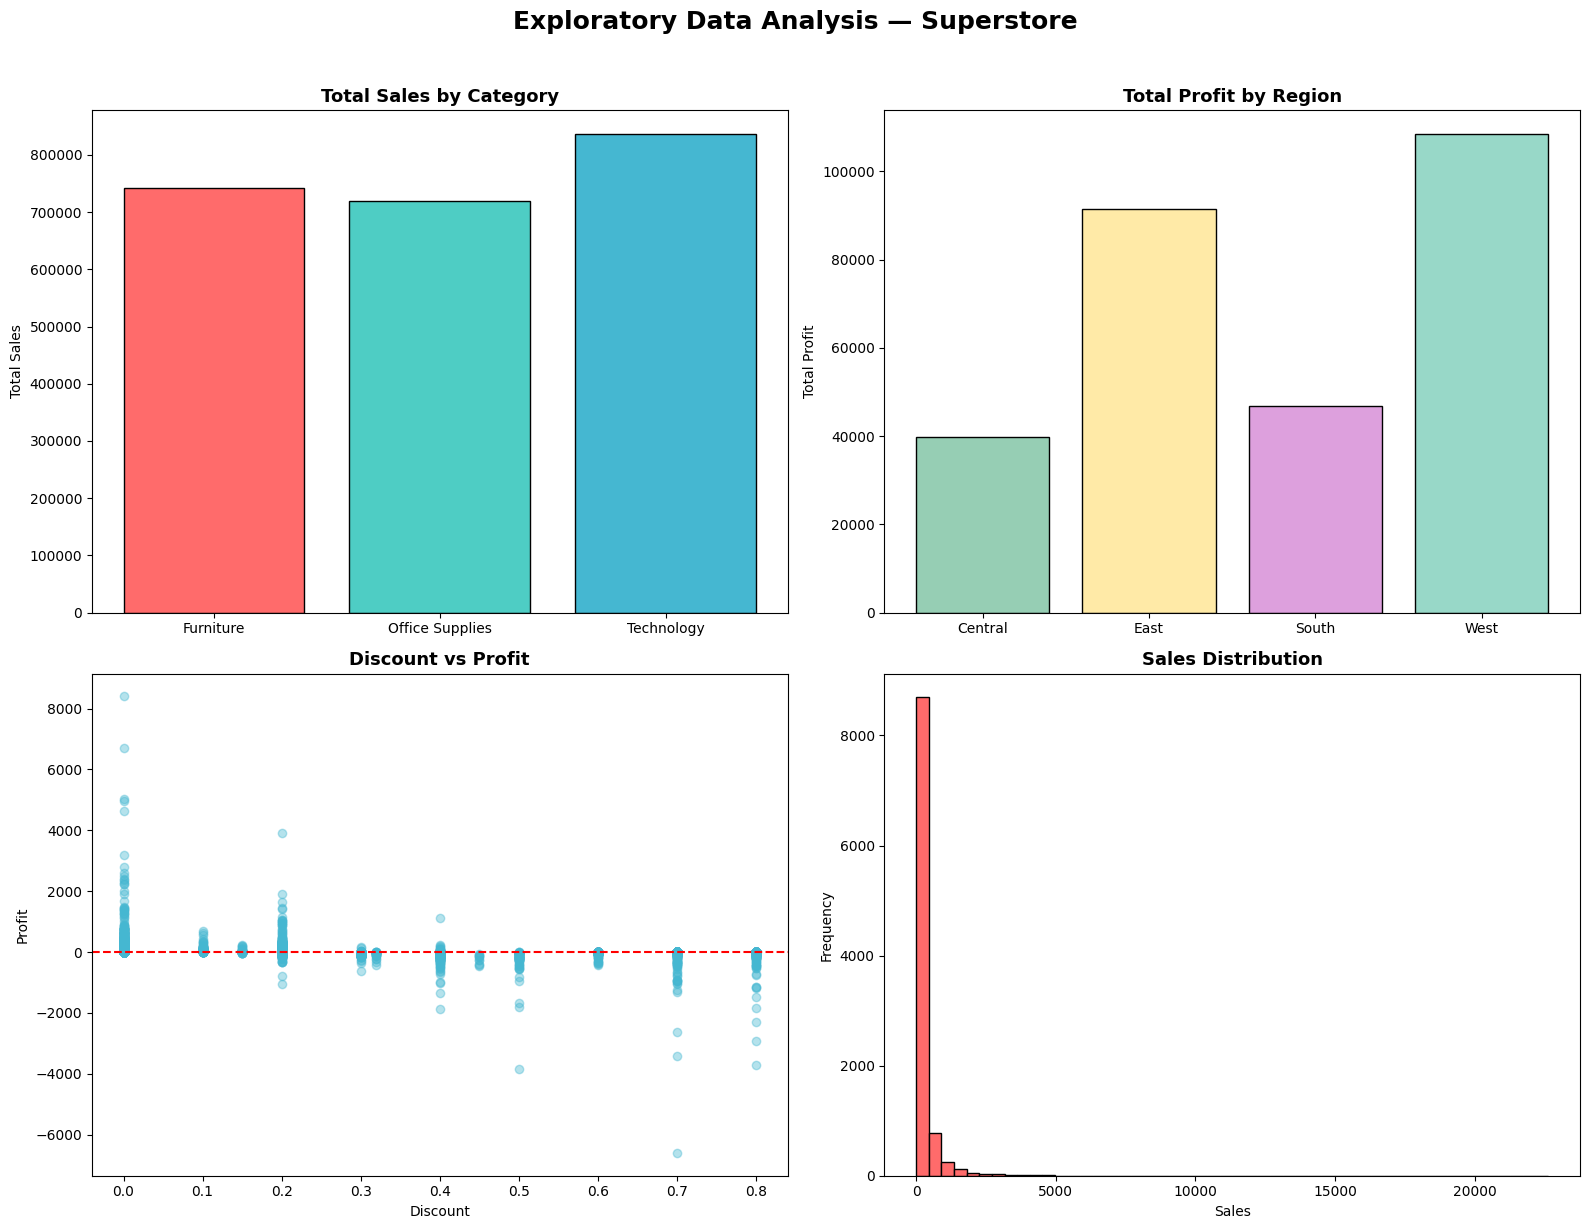

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Superstore', 
             fontsize=18, fontweight='bold', y=1.02)

# Plot 1 — Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum()
axes[0,0].bar(cat_sales.index, cat_sales.values, 
              color=['#FF6B6B','#4ECDC4','#45B7D1'],
              edgecolor='black')
axes[0,0].set_title('Total Sales by Category', 
                     fontweight='bold', fontsize=13)
axes[0,0].set_ylabel('Total Sales')

# Plot 2 — Profit by Region
reg_profit = df.groupby('Region')['Profit'].sum()
axes[0,1].bar(reg_profit.index, reg_profit.values,
              color=['#96CEB4','#FFEAA7','#DDA0DD','#98D8C8'],
              edgecolor='black')
axes[0,1].set_title('Total Profit by Region', 
                     fontweight='bold', fontsize=13)
axes[0,1].set_ylabel('Total Profit')

# Plot 3 — Discount vs Profit
axes[1,0].scatter(df['Discount'], df['Profit'], 
                  alpha=0.4, color='#45B7D1')
axes[1,0].set_title('Discount vs Profit', 
                     fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Discount')
axes[1,0].set_ylabel('Profit')
axes[1,0].axhline(y=0, color='red', linestyle='--')

# Plot 4 — Sales Distribution
axes[1,1].hist(df['Sales'], bins=50, 
               color='#FF6B6B', edgecolor='black')
axes[1,1].set_title('Sales Distribution', 
                     fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Sales')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<p style="color:brown; font-size:18px; font-weight:bold;">CREATE TARGET COLUMN</p> 


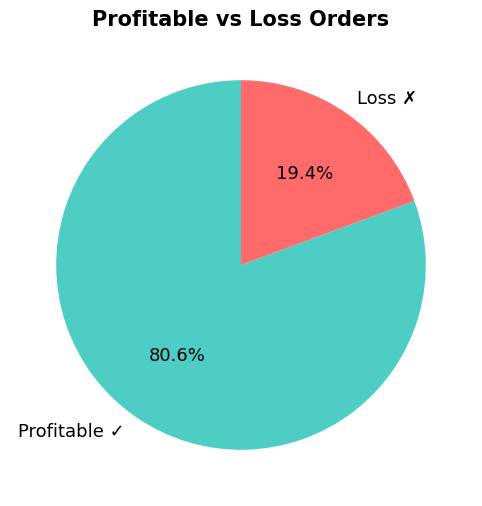

Profitable Orders : 8058 (80.6%)
Loss Orders       : 1936 (19.4%)


In [42]:
df['Profitable'] = (df['Profit'] > 0).astype(int)

profit_counts = df['Profitable'].value_counts()
labels        = ['Profitable ✓', 'Loss ✗']
colors        = ['#4ECDC4', '#FF6B6B']

plt.figure(figsize=(8, 6))
plt.pie(profit_counts.values, 
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 13})
plt.title('Profitable vs Loss Orders', 
          fontsize=15, fontweight='bold')
plt.show()

print(f"Profitable Orders : {profit_counts[1]} ({profit_counts[1]/len(df)*100:.1f}%)")
print(f"Loss Orders       : {profit_counts[0]} ({profit_counts[0]/len(df)*100:.1f}%)")

<p style="color:brown; font-size:18px; font-weight:bold;">FEATURE ENGINEERING</p> 


In [43]:
features = ['Category', 'Sub-Category', 'Region',
            'Segment', 'Ship Mode',
            'Quantity', 'Discount', 'Sales']

X = df[features].copy()
y = df['Profitable']

# Label Encoding
le      = LabelEncoder()
cat_cols = ['Category', 'Sub-Category', 'Region', 
            'Segment', 'Ship Mode']

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print("Features Selected:")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

print("\nEncoding Done! ✓")
print("\nFinal Feature Shape:", X.shape)
X.head()

Features Selected:
  1. Category
  2. Sub-Category
  3. Region
  4. Segment
  5. Ship Mode
  6. Quantity
  7. Discount
  8. Sales

Encoding Done! ✓

Final Feature Shape: (9994, 8)


,Category,Sub-Category,Region,Segment,Ship Mode,Quantity,Discount,Sales
0,0,4,2,0,2,2,0.00,261.9600
1,0,5,2,0,2,3,0.00,731.9400
2,1,10,3,1,2,2,0.00,14.6200
3,0,16,2,0,3,5,0.45,957.5775
4,1,14,2,0,3,2,0.20,22.3680


<p style="color:brown; font-size:18px; font-weight:bold;">TRAIN TEST SPLIT</p> 


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train Test Split — 80% / 20%")
print("=" * 35)
print(f"Total Data  : {len(X)}")
print(f"Train Size  : {len(X_train)} (80%)")
print(f"Test Size   : {len(X_test)}  (20%)")

Train Test Split — 80% / 20%
Total Data  : 9994
Train Size  : 7995 (80%)
Test Size   : 1999  (20%)


<p style="color:brown; font-size:18px; font-weight:bold;">TRAIN MODEL XGBoost</p> 


In [56]:
print("\nTraining XGBoost...")
xgb = XGBClassifier(n_estimators=200, 
                     learning_rate=0.05,
                     max_depth=5, 
                     random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)
print(f"Done! Accuracy: {xgb_acc*100:.2f}%")


Training XGBoost...
Done! Accuracy: 94.45%


<p style="color:brown; font-size:18px; font-weight:bold;">CONFUSION MATRIX (XGBoost)</p> 


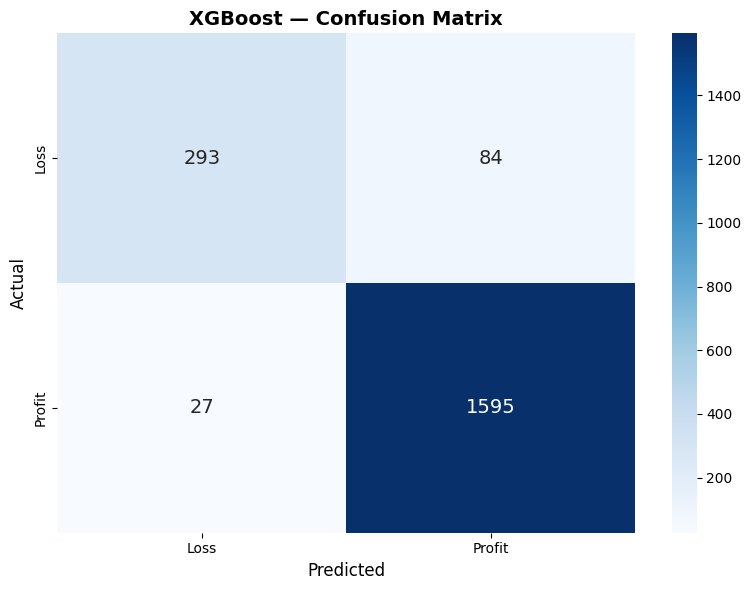

In [47]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Profit'],
            yticklabels=['Loss', 'Profit'],
            annot_kws={'size': 14})
plt.title('XGBoost — Confusion Matrix', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

<p style="color:brown; font-size:18px; font-weight:bold;">FEATURE IMPORTANCE</p> 


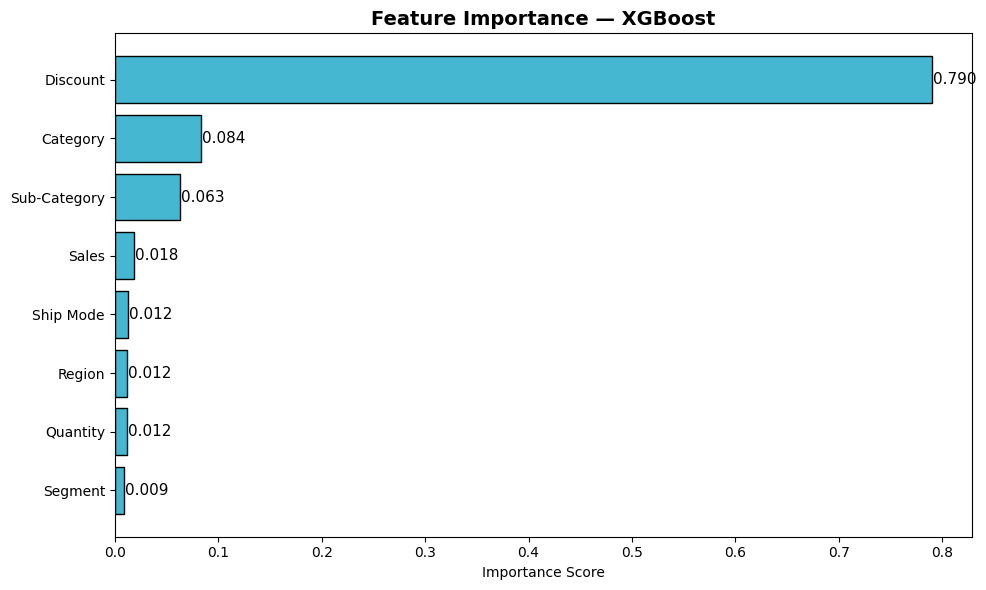

In [59]:
importance = pd.DataFrame({
    'Feature'   : features,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance['Feature'], 
                importance['Importance'],
                color='#45B7D1', edgecolor='black')
plt.title('Feature Importance — XGBoost', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')

for bar, val in zip(bars, importance['Importance']):
    plt.text(bar.get_width() + 0.001, 
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

<p style="color:brown; font-size:18px; font-weight:bold;">FINAL REPORT</p> 


In [61]:
print("=" * 55)
print("\nDetailed XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['Loss', 'Profit']))
print("=" * 55)
print("Conclusion:")
print("Discount is the most important factor")
print("High discount = High chance of Loss!")
print("=" * 55)


Detailed XGBoost Classification Report:
              precision    recall  f1-score   support

        Loss       0.92      0.78      0.84       377
      Profit       0.95      0.98      0.97      1622

    accuracy                           0.94      1999
   macro avg       0.93      0.88      0.90      1999
weighted avg       0.94      0.94      0.94      1999

Conclusion:
Discount is the most important factor
High discount = High chance of Loss!
